# Lineær Diskriminant

Klassifisering er eit standardproblem i statistikk og maskinlæring, som dukkar opp i ei lang rekkje praktiske problem.

I medisinsk biletbehandling kan ein t.d. sjå etter kreftsvulstar på MR-bilete av hjerna. Klassifisering handlar da om å skilja bileta i to klasser, ei med friskt vev og ei med kreftsvulstar.

Eit svært aktuelt problem i finansnæringa er kampen mot kvitvasking, der ein treng å klassifisera transaksjonar i lovlege og ulovlege.

::: {admonition} Definisjon
Eit klassifiseringsproblem ser på ein populasjon av objekt, der kvart objekt har nokre målbare drag (eng. *features*) som me kan observera og kvantifisera, og høyrer til ei klasse (ofte referert til som *label*). For kvart objekt er målet å avgjera kva klasse objektet høyrer til, ved berre å sjå på dei målbare draga. 
:::

I medisinsk biletbehandling kan me t.d. måla fargekvaliteten i kvar einast piksel. I finanstransaksjonar kan me måla tid og stad, avsendar og mottakar, og sjølvsagt beløpet.

Den store pionéren i klassifisering var den britiske statistikaren og biologen Ronald Fisher i mellomkrigstida. Me skal bruka det same datasettet og den same metoden som han brukte, for å illustrera hovudprinsippet for klassifisering. Moderne maskinlæringsalgoritmar gjer i prinsippet akkurat det same, bortsett frå at dei bruker langt fleire variablar; både fleire målbare drag i objekta og fleire fridomsgradar i modellen.

## Fisher sitt datasett

Fisher studerte klassifisering av tre ulike artar av blomen iris. Datasettet som han sette saman er stadig populært for testing av maskinlæringsmodellar. Datasettet omfattar femti eksemplar av kvar iris-art (Iris setosa, Iris virginica og Iris versicolor). Fire målbare drag er registrert for kvart eksemplar: lengd og breidd på beger- og kronblad.

![Iris Versicolor](Iris_versicolor_3.jpg)
Frå [wikimedia commons](https://commons.wikimedia.org/wiki/File:Iris_versicolor_3.jpg) CC-SA-3.0

Me skal bruka scikit-learn, og fordi iris-datasettet er so populært, er det allereie tilgjengeleg i biblioteket. Me kan lasta det slik:

In [57]:
from sklearn import datasets

iris = datasets.load_iris()

display( iris )

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

Datasettet er formattert for `sklearn`, som er forskjellig frå 
det som me er vande med frå `pandas`. 

::: {admonition} Refleksjon
Kva datatype er objektet `iris`?
:::

Mesteparten av datastrukturen er attributten `iris.data` som er ein $150\times4$ *array*.
Det stemmer med tre klasser à 50 eksemplar med fire målbare drag.
Der er òg ein attributt `feature_names`:

In [58]:
print(iris.data.shape)
print(iris.feature_names)

(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


Der ser me altso kva søyle som er kva i datasettet.
Me òg vist `iris.data.shape` som er storleiken på `data`-matrisa.
Dernest legg me merke til det som scikit-learn kaller *target*.

In [59]:
print(iris.target.shape)
print(iris.target_names)

(150,)
['setosa' 'versicolor' 'virginica']


Her har me altso dei tre iris-artane.  Det som me elles kaller 
«klasse» eller *label* heiter altso *target* i scikit-learn.
Kvart artsnamn er koda som eit heiltal (0,1,2) i `iris.target` som
er ein ein-dimensjonal *array* med eitt element for kvar rekkje i
`iris.data`.

Då har me det som me treng, og me skal ikkje bry oss med resten av
datastrukturen.

### Scatter plot

For å få eit visuelt inntrykk av klassifiseringsproblemet, er det
nyttig med spreidingsplott (*scatter plot*).  Det er synd at me 
berre klarer å plotta to søyler i to dimensjonar, men me får ta
det me kan få.

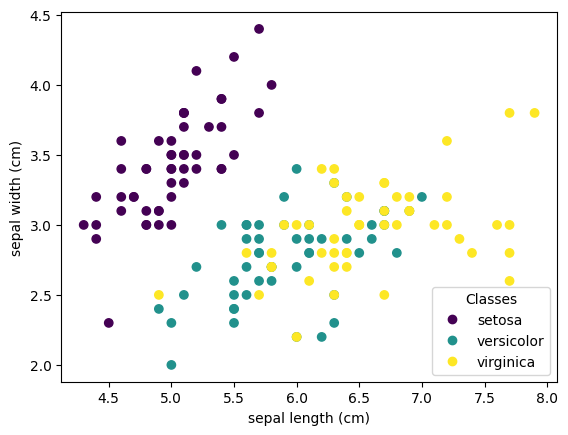

In [60]:
import matplotlib.pyplot as plt

scatter = plt.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)

ax = plt.gca()
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

Her plottar me dei to fyrste søylene. 
Legg merke til korleis me bruker klassene (*target*) til å velja
farge på punkta med `c`-argumentet.


::: {admonition} Oppgåve
Kva gjer `ax.set`?  Og kva gjer `ax.legend`?
(Kva skjer om du fjernar dei?)
:::

Det fyrste argumentet til `ax.legend` er sikkert vondt å forstå.
Poenget med det er å henta ut fargane som er brukt i `scatter`-plottet,
der `scatter` er variabelen som vart tilordna plottet over.
Det andre argumentet er so lista med namn som skal knyttast til fargane.
Inntil vidare er det nok best ikkje å tenkja på korleis det fyrste 
argumentet er konstruert, og berre bruka det som eit fast mynster.

::: {admonition} Refleksjon
Kva irisart plar ha dei breidaste begerblada? 
Kva art plar ha dei lengste?
:::

::: {admonition} Oppgåve
Plott ulike par av søyler frå datasettet.
Kva drag er nyttigast for å identifisera kvar irisart?
:::

## Diskriminant

Løysing åt Fisher er kjend som ein *Lineær Disriminant*.
For å kunna visualisera kva denne diskriminanten gjer, skal
me freista ei klassifisering basert berre på dei to måla som
me plotta over, dvs. lengd og breidd på begerblada.

::: {admonition} Merknad
I dag er der eit par forskjellige formlar for å rekna ut lineære diskriminantar.
Om du les [dokumentasjonen](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html), 
vil du sjå at scikit-learn støttar eit par forskjellige metodar. Me skal ikkje gå inn på skilnadene
eller på kva variant Fisher utvikla i si tid.
:::

Diskriminanten skil mellom to klasser, og me har tre.
Difor skal me fyrst skilja mellom *iris setosa* og *ikkje-setosa*
som den andre klassa.  Lat oss fyrst setja opp datasettet, slik:

<function matplotlib.pyplot.show(close=None, block=None)>

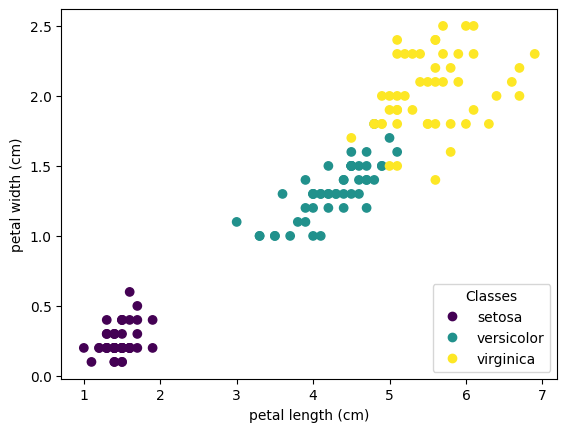

In [61]:
# Oppgave plott ulike par av søyler .....

new_scatter = plt.scatter(iris.data[:, 2], iris.data[:,3], c = iris.target)

new_ax = plt.gca()
new_ax.set(xlabel=iris.feature_names[2], ylabel = iris.feature_names[3])
new_ax.legend(scatter.legend_elements()[0],
              iris.target_names,
              loc="lower right",
                title="Classes")

plt.show

In [62]:
X = iris.data[:,:2]
print( X.shape )
y = iris.target
print( y.shape )

(150, 2)
(150,)


Det er vanleg å bruka $x$ om innvariablane og $y$ om utvariablane.
Her har me altso to innvariablar og éin utvariabel.
Me har derimot tre klasser i $y$, og skulle berre ha to.
Det kan me fiksa slik.

In [63]:
print( y )
y[ y != 0 ] = 1
print( y )

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


Den midste lina er kanskje rar, men me har sett liknande notasjon
med pandas.  Den same notasjonen verkar her, sjølv om dette er numpy
*arrays*. Her set me altso alle $y$-verdiar som ikkje er 0 lik 1.

::: {admonition} Oppgåve
Det er lurt å laga eit plott for å dobbelsjekka at datasettet er det som me hadde tenkt.
Du kan bruka koden over som døme.
Lag eit spreidingsplott av `X` fargekoda med klassene frå `y`.
:::

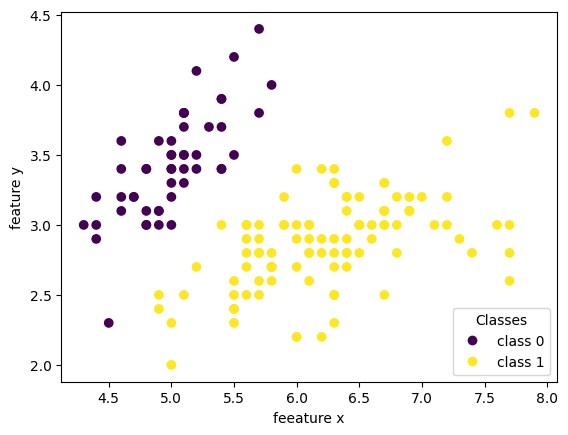

In [64]:
# Oppgave Det er lurt å laga eit plott .......

sc = plt.scatter(X[:,0], X[:,1], c = y)
ax_1 = plt.gca()
ax_1.set(xlabel="feeature x", ylabel="feature y")
ax_1.legend(
    sc.legend_elements()[0],
    ["class 0", "class 1"],
    loc = "lower right",
    title = "Classes"
)
plt.show()

## Den lineære diskriminanten

So er me klare for å laga ein lineær diskriminant.

In [65]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 

lda = LinearDiscriminantAnalysis()  
lda.fit(X,y)
print(lda)
print(lda.coef_)
print(lda.intercept_)

LinearDiscriminantAnalysis()
[[  7.8354964 -11.9506515]]
[-5.80748731]


Her er det mykje som skjer under panseret.
Diskriminanten, som me har instantiert under namnet `lda`, er ein klassifiseringsmodell, 
som me kan bruka til å klassifisera nye blomar.
Dersom me måler lengd `l` og breidd `b` på begerblada, vil `lda.predict(l,b)` gje oss ein *prediksjon* for klassa.
Dette skal me koma tilbake til.

Ein nyinstantiert modell er heilt tilfeldig.
Det er den andre lina `lda.fit` som tilpassar modellen til datasettet.
Dei to koeffisientane `lda.coef_` kaller me ofte for *vektene* i modellen.
Den tredje parameteren `lda.intercept_` kan me kalla konstantleddet
(eller *bias*).
Dei er dei som vert tilpassa av `fit`.

## Visualisering av diskriminanten

Diskriminanten definerer ei line som freistar å skilja dei to klassene frå kvarande.
Før me går inn på bruk av modellen, skal me visualisera han, slik at me veit kva me arbeider med.
Koden under vil vera kryptisk for dei som ikkje har lese ein del matematikk og spesielt lineær algebra,
og det er ikkje viktig å forstå alt. 

Lat oss kalla dei vektene for $x$ og $y$ og konstantleddet for $z$.

In [66]:
x, y = lda.coef_.flatten()
z, = lda.intercept_
print( x, y, z )

7.835496397390882 -11.950651497413784 -5.8074873054868394


Du hugsar kanskje at ei rak line kan skrivast som ei likning eller funksjon $y=\alpha x + \beta$ eller $f(x)=\alpha x+\beta$.
For diskriminanten er denne lina gitt slik at
$\alpha = - x/y$
og
$\beta = -z/y$, eller i kode som:

In [67]:
beta = -z/y
alpha = -x/y
def f(xx): return alpha*xx+beta

Denne lina kan me bruka til å plotta diskriminanten.  Slik

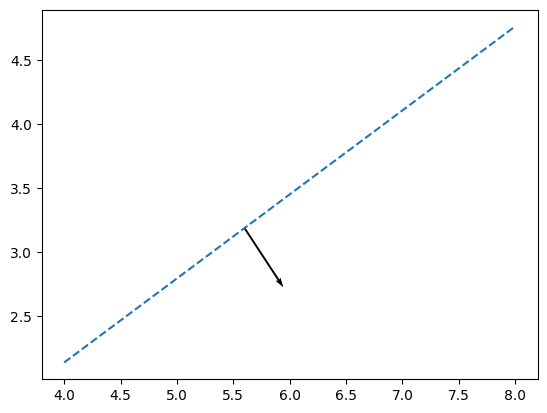

In [68]:
xv = [4, 8]
yv = [ f(xx) for xx in xv ]
ax = plt.subplot()

ax.plot( xv, yv, "--" )

ax.quiver( 5.6, f(5.6), x, y, scale=100, width=2**(-8) )

Pilen som me laga med `quiver()`-funksjonen, markerer normalen på skillelinjen.  Dette er den vektoren som koeffisientane `x` og `y` definerer. Me berre omformulerte dei til ein lineær funksjon for å kunna plotta slik me er vande med.


::: {admonition} Merknad
Om du har eit punkt $(x',y')$ og normalvektoren er $(x,y)$, vil dot-produktet $(x,y)\cdot(x',y')=xx'+yy'$ vera negativ på den eine sida av determinantlina og positiv på den andre. På lina er produktet null. Dess lenger frå lina punktet $(x',y')$ er, dess større er absoluttverdien. Det er altso dette produktet modellen bruker for å predikera klassa for eit nytt objekt $(x',y')$.
:::


::: {admonition} Oppgåve
Lag eit plott som viser både diskriminanten og datasettet, dvs. som kombinerer dei to plotta som er viste.
:::

::: {admonition} Refleksjon
Kva synest du om diskriminanten.  Fungerer han godt på datasettet?
:::

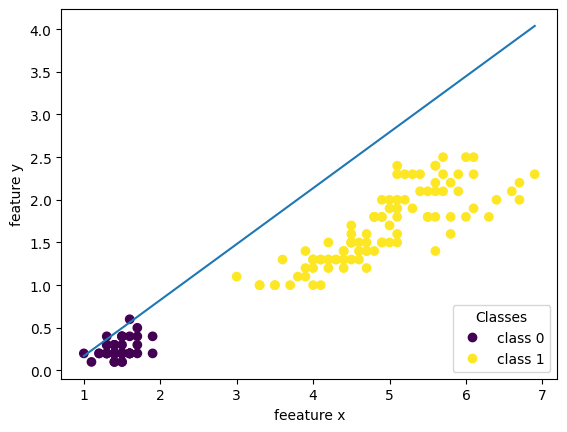

In [69]:
# Lag eit plott som viser både diskriminanten og datasettet, dvs. som kombinerer dei to plotta som er viste.

import numpy as np

# gjenbruker koden fra oppgaven: Det er lurt å laga eit plott .......
sc = plt.scatter(iris.data[:,2], iris.data[:,3], c = iris.target)
ax_1 = plt.gca()
ax_1.set(xlabel="feeature x", ylabel="feature y")
ax_1.legend(
    sc.legend_elements()[0],
    ["class 0", "class 1"],
    loc = "lower right",
    title = "Classes"
)


x_vals = np.linspace(iris.data[:,2].min(),iris.data[:,2].max(), 100)
y_vals = -(lda.coef_[0][0] * x_vals + lda.intercept_[0]) / lda.coef_[0][1]

plt.plot(x_vals, y_vals)
plt.show()


In [ ]:
# Lag diskriminantar som skil ut hhv. *iris versicolor* og 
#*iris virginica*. 


y = iris.target.copy()
y[y !=1] = 0

lda.fit(X,y)

print(lda.coef_)
print(lda.intercept_)

y = iris.target.copy()
y[y!=2] = 0

lda.fit(X,y)

print(lda.coef_)
print(lda.intercept_)

# Vi skiller ut versicolor og viriginica
# Den ene diskriminanten gir en tydelig lineær funksjon, mens den andre gir koeffisienter lik null. 
# Altså den ene er neklere å skille fra de andre klassene mens den andre overlapper mer med resten av datasette,


# 

[[  7.8354964 -11.9506515]]
[-5.80748731]
[[0. 0.]]
[0.]


::: {admonition} Oppgåve
Lag diskriminantar som skil ut hhv. *iris versicolor* og 
*iris virginica*.  Er alle like enkle å skilja på desse to
variablane?
:::

## Prediksjon vha modellen

Lat oss billa oss inn at me har målt tre blomar, og målt begerblada.
Me skriv kvar blome som ei liste med [*lengd*, *breidd*].

In [71]:
import numpy as np
x1 = np.array([[ 4.4, 3.5 ]])
x2 = np.array([[ 4.8, 2.5 ]])
x3 = np.array([[ 7.5, 2.6 ]])

No kan me sjekka kva modellen meiner om desse blomane.

In [12]:
for x in [ x1, x2, x3 ]:
   print( f"{x} -> {lda.predict(x)}" )

[[4.4 3.5]] -> [0]
[[4.8 2.5]] -> [1]
[[7.5 2.6]] -> [1]


::: {admonition} Refleksjon
Kva gjer koden min over?
Kva tyder tala over?
:::

Me skal sjå at modellen predikerer setosa (0) for den fyrste, og ikkje for dei to andre.

Lat oss sjå korleis det ser ut i spreidingsplottet òg.
Me legg til dei tre nye blomane med kross i plottet for å skilja dei
frå treningssettet, slik:

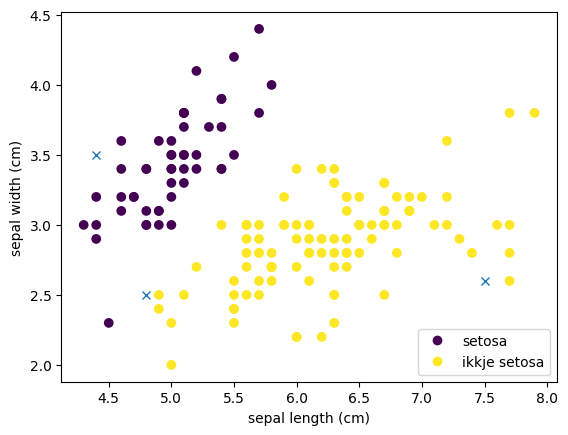

In [13]:
ax = plt.subplot()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
ax.legend(
    scatter.legend_elements()[0], ["setosa", "ikkje setosa"], loc="lower right"
)

xn = [ x[0,0] for x in [ x1, x2, x3 ] ]
yn = [ x[0,1] for x in [ x1, x2, x3 ] ]
ax.plot( xn, yn, "x" )

## Oppsummering

Det me har vist her er ikkje berre ein metode som var hipp og kul på
1930-talet og for lengst forelda.
Me har vist hovudprinsippet for mange moderne maskinlæringsmetodar òg.
Den store skilnaden er at den lineære modellen berre har to vekter,
eller generelt éi vekt per *input*-variabel.
Djupe nevrale nettverk kan ha mange milliardar vekter.  Dei er heller
ikkje lineære.
Når djupe nevrale nettverk vert brukte til klassifisering, definerer
dei ei ikkje-lineær hyperflate som skiljer to klasser.

Der er to viktige ting som me ikkje har vist her:
+ Lineær diskriminant med meir enn to *inputs*.
+ Evaluering av modellen.
Dette skal me koma tilbake til.

+ Meir dokumentasjonen på sklearn
    +  [datasets.load_iris](https://scikit-learn.org/1.4/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris "sklearn.datasets.load_iris")
    + [LinearDiscriminantAnalysis](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)